# Employee Attrition Analytics

## Module 5: Statistical Analysis

### Objective
Apply descriptive and inferential statistics to understand employee behavior and identify statistically meaningful relationships.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats

## Load Clean Dataset

In [3]:
df = pd.read_csv("../data/processed/employee_hr_analytics_clean.csv")
df.head()

,Employee_ID,Age,Gender,Department,Job_Role,Experience,Education,Salary,Performance_Score,Job_Satisfaction,...,Remote_Work,Training_Hours,Projects,Promotion_Last_5Yrs,Joining_Date,Attrition,City,Employment_Type,Manager_Rating,Sick_Leaves
0,1,40.0,Male,Sales,Sales Manager,3,Master,94113.0,5,6.0,...,No,70,5,No,2011-12-21,No,Rawalpindi,Contract,5,6
1,2,39.0,Female,Sales,Sales Manager,2,Master,54224.0,4,9.0,...,No,33,3,Yes,2015-09-20,No,Islamabad,Full-Time,4,4
2,3,49.0,Male,Finance,Financial Analyst,25,Master,166749.0,2,6.0,...,Yes,75,12,No,2014-12-10,No,Islamabad,Full-Time,8,2
3,4,54.0,Female,Marketing,Marketing Specialist,26,Bachelor,196590.0,5,4.0,...,Yes,64,12,No,2022-08-23,Yes,Rawalpindi,Contract,4,5
4,5,41.0,Female,IT,Data Analyst,18,PhD,231764.0,3,8.0,...,Yes,15,12,No,2021-09-29,No,Rawalpindi,Contract,10,8


## Mean, Median, and Mode

In [4]:
salary_mean = df["Salary"].mean()
salary_median = df["Salary"].median()
salary_mode = df["Salary"].mode()[0]

print("Mean Salary:", round(salary_mean, 2))
print("Median Salary:", round(salary_median, 2))
print("Mode Salary:", salary_mode)

Mean Salary: 127969.24
Median Salary: 119197.5
Mode Salary: 119197.5


## Variance and Standard Deviation

In [5]:
salary_variance = df["Salary"].var()
salary_std = df["Salary"].std()

print("Salary Variance:", round(salary_variance, 2))
print("Salary Standard Deviation:", round(salary_std, 2))

Salary Variance: 3927984224.04
Salary Standard Deviation: 62673.63


## Salary Quartiles

In [6]:
Q1 = df["Salary"].quantile(0.25)
Q2 = df["Salary"].quantile(0.50)
Q3 = df["Salary"].quantile(0.75)

print("Q1:", Q1)
print("Q2 / Median:", Q2)
print("Q3:", Q3)

Q1: 69628.5
Q2 / Median: 119197.5
Q3: 182615.25


## Salary Percentiles

In [7]:
percentiles = df["Salary"].quantile([0.10, 0.25, 0.50, 0.75, 0.90])
percentiles

0.10     51443.50
0.25     69628.50
0.50    119197.50
0.75    182615.25
0.90    219796.60
Name: Salary, dtype: float64

## Salary Range and IQR

In [8]:
salary_range = df["Salary"].max() - df["Salary"].min()

IQR = Q3 = Q1

print("Salary Range:", salary_range)
print("Salary IQR:", IQR)

Salary Range: 312056.375
Salary IQR: 69628.5


## Salary Distribution

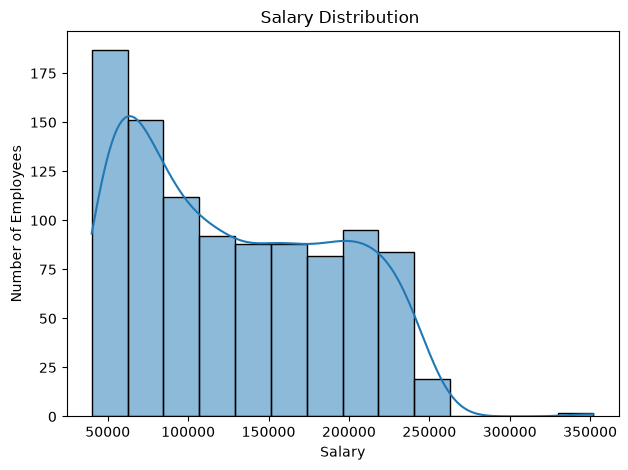

In [9]:
plt.Figure(figsize=(9, 5))

sns.histplot(data=df, x="Salary", kde=True)

plt.title("Salary Distribution ")
plt.xlabel("Salary")
plt.ylabel("Number of Employees")

plt.tight_layout()
plt.show()

## Salary Skewness

In [11]:
salary_skewness = df["Salary"].skew()
print("Salary Skewness:", round(salary_skewness, 2))

Salary Skewness: 0.36


## Experience and Salary Correlation

In [14]:
correlation = df["Experience"].corr(df["Salary"])
print("Correlation between Experience and Salary:", round(correlation, 3))

Correlation between Experience and Salary: 0.82


## Pearson Correlation Test

In [15]:
correlation, p_value = stats.pearsonr(df["Experience"], df["Salary"])

print("Correlation:", round(correlation, 3))
print("P-Value:", p_value)

Correlation: 0.82
P-Value: 1.3657976972098424e-244


## Hypothesis Test: Overtime and Job Satisfaction

### Business Question

Is average job satisfaction different between employees who work overtime and employees who do not?

### Null Hypothesis (H₀)

There is no difference in mean job satisfaction between the two groups.

### Alternative Hypothesis (H₁)

There is a difference in mean job satisfaction between the two groups.

### Significance Level

α = 0.05

In [18]:
overtime_yes = df.loc[df["Overtime"] == "Yes", "Job_Satisfaction"]

overtime_no = df.loc[df["Overtime"] == "No", "Job_Satisfaction"]

print("Overtime employees:", len(overtime_yes))
print("Non-overtime employees:", len(overtime_no))

Overtime employees: 490
Non-overtime employees: 510


## Compare Group Means

In [19]:
print("Average satisfaction - Overtime:", round(overtime_yes.mean(), 2))

print("Average satisfaction - No Overtime:", round(overtime_no.mean(), 2))

Average satisfaction - Overtime: 5.5
Average satisfaction - No Overtime: 7.94


## Independent Samples T-Test

In [20]:
t_statistic, p_value = stats.ttest_ind(overtime_yes, overtime_no, equal_var=False)

print("T-statistic:", round(t_statistic, 3))
print("P-value:", p_value)

T-statistic: -24.977
P-value: 2.958077646421563e-106


## Interpret T-Test

In [21]:
alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis.")
    print(
        "There is statistically significant evidence of a difference in job satisfaction."
    )
else:
    print("Fail to reject the null hypothesis.")
    print("There is not enough evidence of a difference in job satisfaction.")

Reject the null hypothesis.
There is statistically significant evidence of a difference in job satisfaction.


## Chi-Square Test: Overtime and Attrition

### Business Question

Is employee overtime status associated with attrition?

### Null Hypothesis (H₀)

Overtime and attrition are independent.

### Alternative Hypothesis (H₁)

Overtime and attrition are associated.

### Significance Level

α = 0.05

In [22]:
contingency_table = pd.crosstab(df["Overtime"], df["Attrition"])

contingency_table

Attrition,No,Yes
Overtime,,
No,510,0
Yes,372,118


## Perform Chi-Square Test

In [23]:
chi2, p_value, degrees_of_freedom, expected = stats.chi2_contingency(contingency_table)

print("Chi-square statistic:", round(chi2, 3))
print("P-value:", p_value)
print("Degrees of freedom:", degrees_of_freedom)

Chi-square statistic: 136.943
P-value: 1.2407808265401103e-31
Degrees of freedom: 1


## Interpret Chi-Square Test

In [24]:
alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis.")
    print(
        "There is statistically significant evidence of an association between overtime and attrition."
    )
else:
    print("Fail to reject the null hypothesis.")
    print(
        "There is not enough evidence of an association between overtime and attrition."
    )

Reject the null hypothesis.
There is statistically significant evidence of an association between overtime and attrition.


## Attrition Rate by Overtime

In [25]:
attrition_by_overtime = df.groupby("Overtime")["Attrition"].apply(
    lambda x: (x == "Yes").mean() * 100
)

attrition_by_overtime

Overtime
No      0.000000
Yes    24.081633
Name: Attrition, dtype: float64

## Attrition Rate Difference

In [26]:
overtime_attrition_rate = attrition_by_overtime["Yes"]
non_overtime_attrition_rate = attrition_by_overtime["No"]

difference = overtime_attrition_rate - non_overtime_attrition_rate

print(f"Attrition rate difference: {difference:.2f} percentage points")

Attrition rate difference: 24.08 percentage points


## Statistical Summary

In [28]:
print("STATISTICAL SUMMARY")
print("=" * 40)

print(f"Mean Salary: {df['Salary'].mean():,.2f}")
print(f"Median Salary: {df['Salary'].median():,.2f}")
print(f"Salary Std: {df['Salary'].std():,.2f}")
print(f"Salary Skewness: {df['Salary'].skew():.3f}")

print(f"\nExperience-Salary Correlation: {df['Experience'].corr(df['Salary']):.3f}")

print(f"\nOverall Attrition Rate: {(df['Attrition'] == 'Yes').mean() * 100:.2f}%")

print(f"\nOvertime Attrition Rate: {overtime_attrition_rate:.2f}%")

print(f"Non-Overtime Attrition Rate: {non_overtime_attrition_rate:.2f}%")

STATISTICAL SUMMARY
Mean Salary: 127,969.24
Median Salary: 119,197.50
Salary Std: 62,673.63
Salary Skewness: 0.355

Experience-Salary Correlation: 0.820

Overall Attrition Rate: 11.80%

Overtime Attrition Rate: 24.08%
Non-Overtime Attrition Rate: 0.00%


## Save Statistical Results

In [ ]:
statistics_summary = {
    "Mean_Salary": df["Salary"].mean(),
    "Median_Salary": df["Salary"].median(),
    "Salary_Std": df["Salary"].std(),
    "Salary_Skewness": df["Salary"].skew(),
    "Experience_Salary_Correlation": df["Experience"].corr(df["Salary"]),
    "Overall_Attrition_Rate": (df["Attrition"] == "Yes").mean() * 100,
    "Overtime_Attrition_Rate": overtime_attrition_rate,
    "Non_Overtime_Attrition_Rate": non_overtime_attrition_rate,
    "T_Test_P_Value": p_value,
}

statistics_df = pd.DataFrame([statistics_summary])

statistics_df

,Mean_Salary,Median_Salary,Salary_Std,Salary_Skewness,Experience_Salary_Correlation,Overall_Attrition_Rate,Overtime_Attrition_Rate,Non_Overtime_Attrition_Rate,T_Test_P_Value
0,127969.24125,119197.5,62673.632606,0.355148,0.820469,11.8,24.081633,0.0,1.240781e-31


In [30]:
statistics_df.to_csv("../data/processed/statistical_summary.csv", index=False)

print("Statistical summary saved successfully.")

Statistical summary saved successfully.
